
# Solver Benchmarks: Damped Oscillator

This notebook benchmarks several classical ODE solvers on the **damped harmonic oscillator**
$$
\dot{x} = v,\qquad \dot{v} = -\omega^2 x - \gamma v.
$$


## What this notebook does
1. Defines the damped oscillator.
2. Computes a high-accuracy reference solution.
3. Benchmarks several `scipy.integrate.solve_ivp` methods.
4. Measures:
   - relative trajectory error,
   - terminal error,
   - runtime,
   - number of function evaluations (NFE),
   - number of accepted steps.
5. Produces tables and figures suitable for later thesis use.


In [19]:

# Standard scientific Python imports
from pathlib import Path
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Plot style
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Reproducibility
np.random.seed(0)



## 1. Output directory and benchmark settings

You can change the output directory below to match your repo structure.


In [20]:

# Change this if needed
OUTPUT_DIR = Path("results/solver_benchmarks/damped_oscillator")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Solver methods to compare
METHODS = ["RK23", "RK45", "DOP853", "Radau", "BDF", "LSODA"]

# Benchmark tolerances
RTOL = 1e-6
ATOL = 1e-8

# High-accuracy reference solve
REFERENCE_METHOD = "DOP853"
REFERENCE_RTOL = 1e-12
REFERENCE_ATOL = 1e-14

# Damped oscillator parameters
OMEGA = 2.0
GAMMA = 0.2

# Initial condition and time interval
Y0 = np.array([2.0, 0.0], dtype=float)
T_SPAN = (0.0, 20.0)
T_EVAL = np.linspace(T_SPAN[0], T_SPAN[1], 800)

OUTPUT_DIR


PosixPath('results/solver_benchmarks/damped_oscillator')

## 2. Define the dynamical system

In [21]:

def damped_oscillator_rhs(t, y, omega=OMEGA, gamma=GAMMA):
    x, v = y
    return np.array([v, -(omega ** 2) * x - gamma * v], dtype=float)


def relative_l2_error(pred, ref):
    denom = np.linalg.norm(ref)
    if denom == 0.0:
        return float(np.linalg.norm(pred - ref))
    return float(np.linalg.norm(pred - ref) / denom)


def componentwise_max_abs_error(pred, ref):
    return float(np.max(np.abs(pred - ref)))


## 3. Compute a high-accuracy reference solution

In [22]:

reference_sol = solve_ivp(
    fun=damped_oscillator_rhs,
    t_span=T_SPAN,
    y0=Y0,
    method=REFERENCE_METHOD,
    t_eval=T_EVAL,
    rtol=REFERENCE_RTOL,
    atol=REFERENCE_ATOL,
    dense_output=True,
)

if not reference_sol.success:
    raise RuntimeError(f"Reference solve failed: {reference_sol.message}")

reference = reference_sol.y
np.savez(OUTPUT_DIR / "reference_solution.npz", t=T_EVAL, y=reference)

print("Reference solve successful.")
print("Reference method:", REFERENCE_METHOD)
print("Reference nfev:", reference_sol.nfev)
print("Saved:", OUTPUT_DIR / "reference_solution.npz")


Reference solve successful.
Reference method: DOP853
Reference nfev: 3407
Saved: results/solver_benchmarks/damped_oscillator/reference_solution.npz


## 4. Visualize the reference trajectory

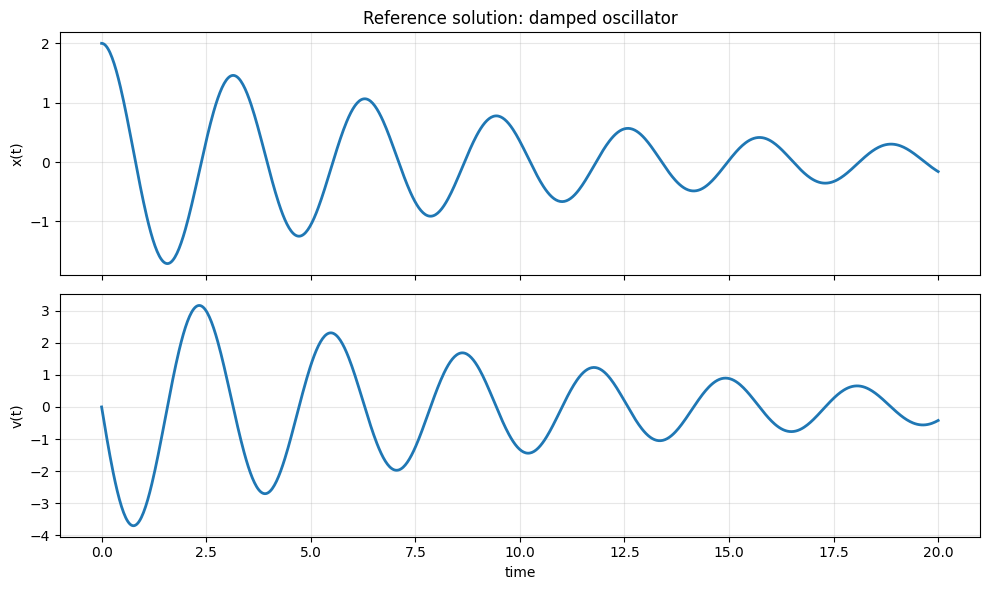

In [23]:

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(T_EVAL, reference[0], linewidth=2.0)
axes[0].set_ylabel("x(t)")
axes[0].set_title("Reference solution: damped oscillator")

axes[1].plot(T_EVAL, reference[1], linewidth=2.0)
axes[1].set_ylabel("v(t)")
axes[1].set_xlabel("time")

fig.tight_layout()
plt.show()


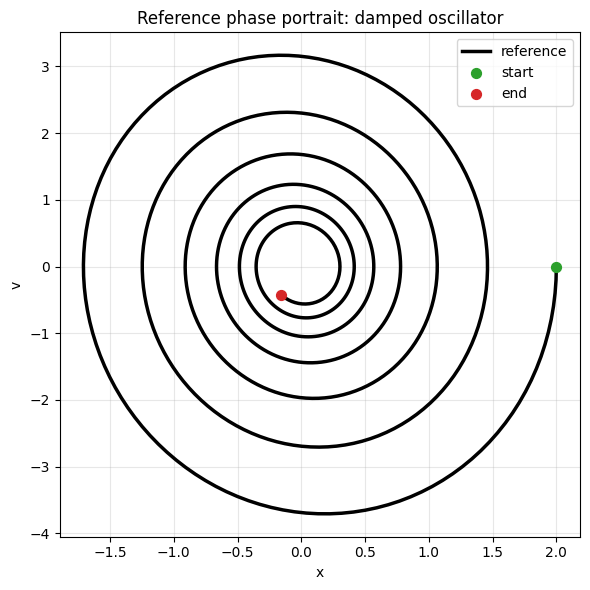

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(
    reference[0],   # x(t)
    reference[1],   # v(t)
    linewidth=2.5,
    color="black",
    label="reference",
)

# Optional: mark start and end of the trajectory
ax.scatter(reference[0, 0], reference[1, 0], color="tab:green", s=50, zorder=3, label="start")
ax.scatter(reference[0, -1], reference[1, -1], color="tab:red", s=50, zorder=3, label="end")

ax.set_xlabel("x")
ax.set_ylabel("v")
ax.set_title("Reference phase portrait: damped oscillator")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "damped_oscillator_reference_phase_portrait.png", dpi=180)
plt.show()


## 5. Benchmark candidate solvers

In [25]:

rows = []
solver_solutions = {}
step_histories = {}

for method in METHODS:
    start = time.perf_counter()
    sol = solve_ivp(
        fun=damped_oscillator_rhs,
        t_span=T_SPAN,
        y0=Y0,
        method=method,
        t_eval=T_EVAL,
        rtol=RTOL,
        atol=ATOL,
        dense_output=False,
    )
    runtime_sec = time.perf_counter() - start

    row = {
        "system": "damped_oscillator",
        "method": method,
        "rtol": RTOL,
        "atol": ATOL,
        "runtime_sec": runtime_sec,
        "success": bool(sol.success),
        "status": int(sol.status),
        "message": sol.message,
        "nfev": int(getattr(sol, "nfev", -1)),
        "njev": int(getattr(sol, "njev", -1)),
        "nlu": int(getattr(sol, "nlu", -1)),
        "n_steps": int(max(0, len(sol.t) - 1)),
    }

    if sol.success and sol.y.shape == reference.shape:
        pred = sol.y
        solver_solutions[method] = pred
        step_histories[method] = (sol.t, np.diff(sol.t))
        row["rel_l2_error"] = relative_l2_error(pred, reference)
        row["max_abs_error"] = componentwise_max_abs_error(pred, reference)
        row["terminal_abs_error"] = float(np.linalg.norm(pred[:, -1] - reference[:, -1]))
        np.savez(OUTPUT_DIR / f"solution_{method}.npz", t=T_EVAL, y=pred)
    else:
        row["rel_l2_error"] = math.nan
        row["max_abs_error"] = math.nan
        row["terminal_abs_error"] = math.nan

    rows.append(row)

benchmark_df = pd.DataFrame(rows).sort_values(
    ["success", "rel_l2_error", "nfev"],
    ascending=[False, True, True]
).reset_index(drop=True)

benchmark_df.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)

print("Saved summary to:", OUTPUT_DIR / "benchmark_summary.csv")
benchmark_df


Saved summary to: results/solver_benchmarks/damped_oscillator/benchmark_summary.csv


,system,method,rtol,atol,runtime_sec,success,status,message,nfev,njev,nlu,n_steps,rel_l2_error,max_abs_error,terminal_abs_error
0,damped_oscillator,Radau,0.000001,1.000000e-08,0.031381,True,0,The solver successfully reached the end of the...,3100,2,36,799,6.129383e-08,4.323802e-07,1.830049e-08
1,damped_oscillator,DOP853,0.000001,1.000000e-08,0.002554,True,0,The solver successfully reached the end of the...,629,0,0,799,1.200279e-06,5.509714e-06,1.390493e-06
2,damped_oscillator,RK45,0.000001,1.000000e-08,0.006637,True,0,The solver successfully reached the end of the...,1340,0,0,799,1.712456e-06,4.067519e-06,2.625158e-06
3,damped_oscillator,RK23,0.000001,1.000000e-08,0.033515,True,0,The solver successfully reached the end of the...,5105,0,0,799,1.085727e-05,2.576992e-05,1.420840e-05
4,damped_oscillator,LSODA,0.000001,1.000000e-08,0.006106,True,0,The solver successfully reached the end of the...,874,8,8,799,1.580143e-05,3.918996e-05,2.109279e-05
5,damped_oscillator,BDF,0.000001,1.000000e-08,0.015822,True,0,The solver successfully reached the end of the...,774,1,69,799,3.142418e-05,7.415668e-05,4.518314e-05



## 6. Summary table

The most important quantities for the thesis are usually:
- `rel_l2_error`
- `terminal_abs_error`
- `runtime_sec`
- `nfev`
- `n_steps`


In [26]:

summary_cols = [
    "method",
    "success",
    "rel_l2_error",
    "terminal_abs_error",
    "runtime_sec",
    "nfev",
    "n_steps",
    "njev",
    "nlu",
]
benchmark_df[summary_cols]


,method,success,rel_l2_error,terminal_abs_error,runtime_sec,nfev,n_steps,njev,nlu
0,Radau,True,6.129383e-08,1.830049e-08,0.031381,3100,799,2,36
1,DOP853,True,1.200279e-06,1.390493e-06,0.002554,629,799,0,0
2,RK45,True,1.712456e-06,2.625158e-06,0.006637,1340,799,0,0
3,RK23,True,1.085727e-05,1.420840e-05,0.033515,5105,799,0,0
4,LSODA,True,1.580143e-05,2.109279e-05,0.006106,874,799,8,8
5,BDF,True,3.142418e-05,4.518314e-05,0.015822,774,799,1,69


## 7. Trajectory overlays

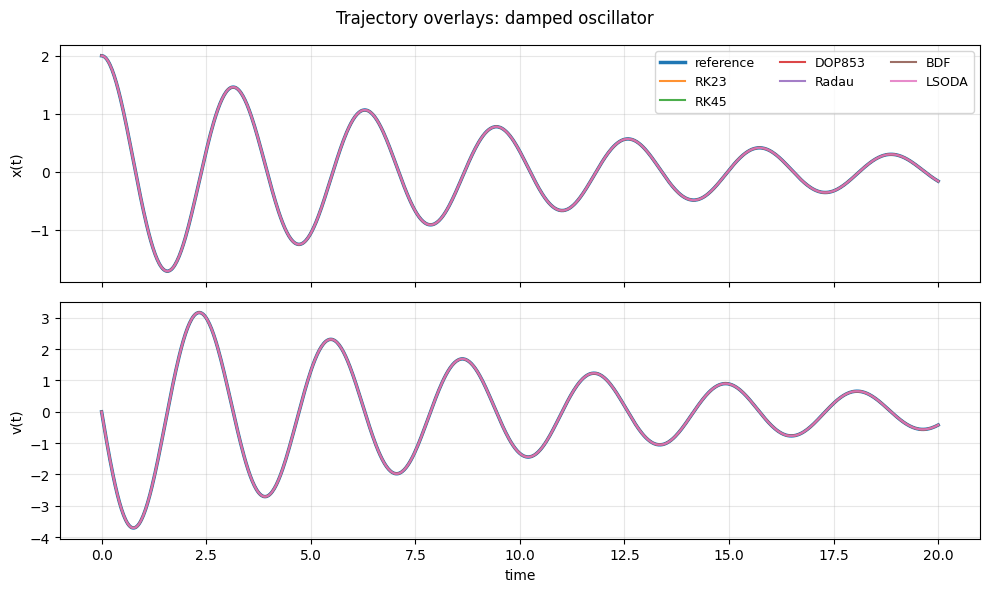

In [27]:

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(T_EVAL, reference[i], label="reference", linewidth=2.5)
    for method, pred in solver_solutions.items():
        ax.plot(T_EVAL, pred[i], label=method, alpha=0.85)
    ax.set_ylabel("x(t)" if i == 0 else "v(t)")

axes[-1].set_xlabel("time")
axes[0].legend(ncol=3, fontsize=9)
fig.suptitle("Trajectory overlays: damped oscillator")
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "damped_oscillator_trajectories.png", dpi=180)
plt.show()


## 8. Error versus NFE

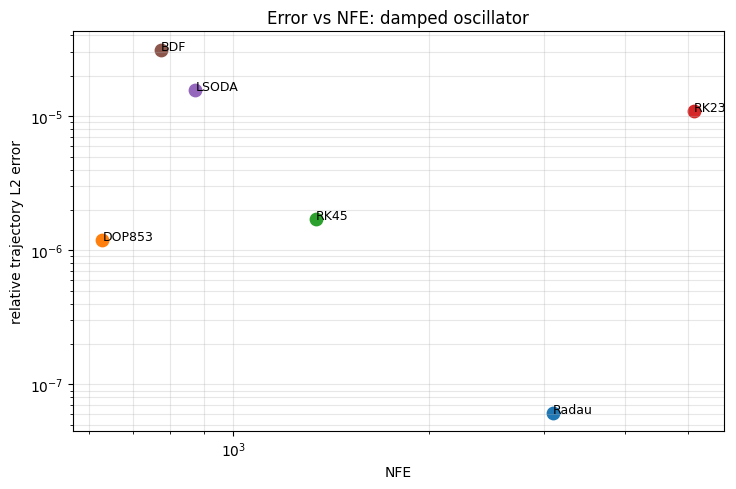

In [28]:

successful = benchmark_df[benchmark_df["success"] == True].copy()

fig, ax = plt.subplots(figsize=(7.5, 5.0))
for _, row in successful.iterrows():
    ax.scatter(row["nfev"], row["rel_l2_error"], s=80)
    ax.annotate(str(row["method"]), (row["nfev"], row["rel_l2_error"]), fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("NFE")
ax.set_ylabel("relative trajectory L2 error")
ax.set_title("Error vs NFE: damped oscillator")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "damped_oscillator_error_vs_nfe.png", dpi=180)
plt.show()


## 9. Error versus runtime

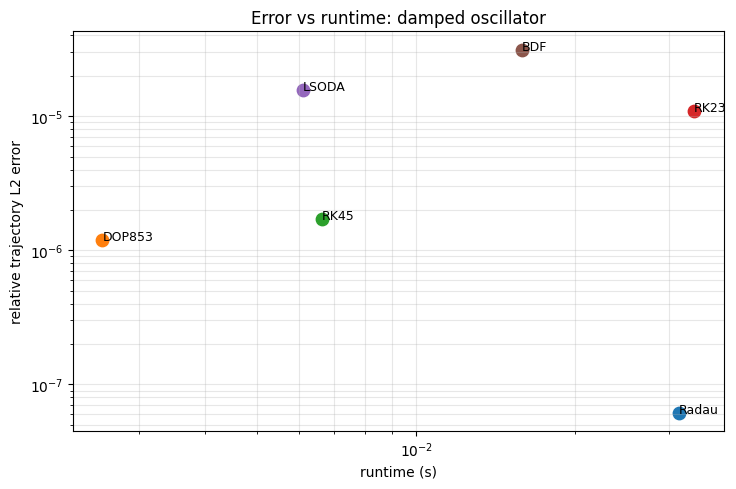

In [29]:

fig, ax = plt.subplots(figsize=(7.5, 5.0))
for _, row in successful.iterrows():
    ax.scatter(row["runtime_sec"], row["rel_l2_error"], s=80)
    ax.annotate(str(row["method"]), (row["runtime_sec"], row["rel_l2_error"]), fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("runtime (s)")
ax.set_ylabel("relative trajectory L2 error")
ax.set_title("Error vs runtime: damped oscillator")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "damped_oscillator_error_vs_runtime.png", dpi=180)
plt.show()



## 10. Accepted step sizes

This plot is especially useful later when you compare non-stiff and stiff systems.
For the damped oscillator, explicit adaptive methods should behave comfortably.


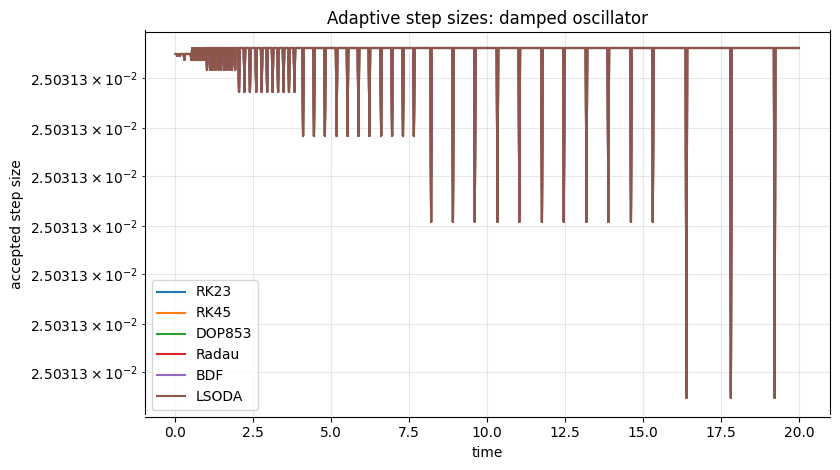

In [30]:

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for method, (t, h) in step_histories.items():
    if len(h) == 0:
        continue
    ax.plot(t[1:], h, label=method)

ax.set_yscale("log")
ax.set_xlabel("time")
ax.set_ylabel("accepted step size")
ax.set_title("Adaptive step sizes: damped oscillator")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "damped_oscillator_step_sizes.png", dpi=180)
plt.show()



## 11. Phase portrait

This is optional, but it often makes the behavior easier to interpret in the thesis text.


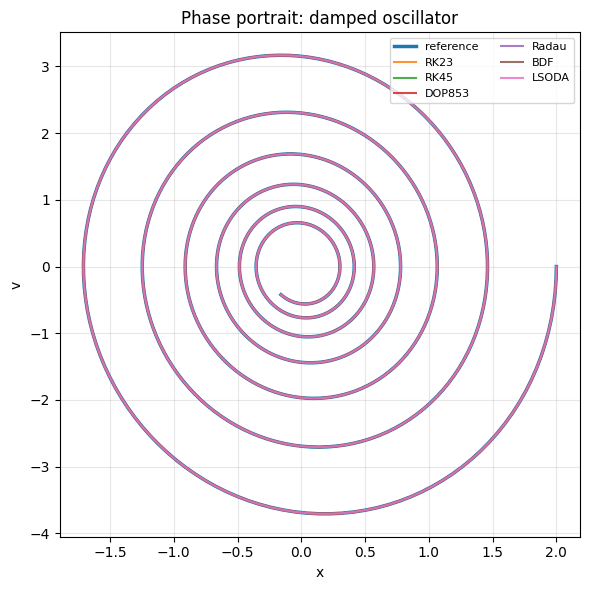

In [31]:

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(reference[0], reference[1], label="reference", linewidth=2.5)
for method, pred in solver_solutions.items():
    ax.plot(pred[0], pred[1], label=method, alpha=0.85)

ax.set_xlabel("x")
ax.set_ylabel("v")
ax.set_title("Phase portrait: damped oscillator")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "damped_oscillator_phase_portrait.png", dpi=180)
plt.show()


In [32]:

# print the output files created by this notebook
sorted(str(p.name) for p in OUTPUT_DIR.iterdir())


['benchmark_summary.csv',
 'damped_oscillator_error_vs_nfe.png',
 'damped_oscillator_error_vs_runtime.png',
 'damped_oscillator_phase_portrait.png',
 'damped_oscillator_reference_phase_portrait.png',
 'damped_oscillator_step_sizes.png',
 'damped_oscillator_trajectories.png',
 'reference_solution.npz',
 'solution_BDF.npz',
 'solution_DOP853.npz',
 'solution_LSODA.npz',
 'solution_RK23.npz',
 'solution_RK45.npz',
 'solution_Radau.npz']